### Conditional workflow without using any LLM

In [10]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal

In [ ]:
class ModerationState(TypedDict):
    post_content: str
    user_reputation: str

    formatted_post: str
    content_flag: str
    result: str  # Only 1 result out of these 3 condition will be stored so no need of reducers.

In [3]:
def format_post(state: ModerationState):
    # Mirrors 'show_equation' from the original
    formatted = f"User ({state['user_reputation']}) says: {state['post_content']}"
    return {'formatted_post': formatted}

In [4]:
def analyze_content(state: ModerationState):
    content = state['post_content'].lower()

    # Simple mock logic for content moderation
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state['user_reputation'] == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'

    return {'content_flag': flag}

In [5]:
def approve_post(state: ModerationState):
    result = 'Post published successfully to the timeline.'
    return {'result': result}

In [6]:
def flag_for_review(state: ModerationState):
    result = 'Post sent to the human moderation queue.'
    return {'result': result}

In [7]:
def reject_post(state: ModerationState):
    result = 'Post automatically deleted due to policy violation.'
    return {'result': result}

In [12]:
def check_condition(state: ModerationState) -> Literal["approve_post", "flag_for_review", "reject_post"]:
    # Mirrors the conditional routing based on the discriminant in the original
    if state['content_flag'] == 'approved':
        return "approve_post"
    elif state['content_flag'] == 'review':
        return "flag_for_review"
    else:
        return "reject_post"

In [13]:
graph = StateGraph(ModerationState)

# add the nodes
graph.add_node('format_post', format_post)
graph.add_node('analyze_content', analyze_content)
graph.add_node('approve_post', approve_post)
graph.add_node('flag_for_review', flag_for_review)
graph.add_node('reject_post', reject_post)

# add the edges
graph.add_edge(START, 'format_post')
graph.add_edge('format_post', 'analyze_content')

# Add conditional edges
graph.add_conditional_edges('analyze_content', check_condition)

# Connect all branches to END
graph.add_edge('approve_post', END)
graph.add_edge('flag_for_review', END)
graph.add_edge('reject_post', END)

workflow = graph.compile()

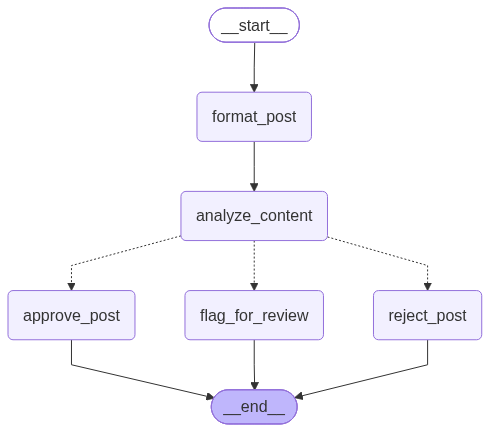

In [14]:
workflow

In [15]:
initial_state = {
    'post_content': "Check out this amazing new product! Buy now!",
    'user_reputation': "trusted_user"
}

workflow.invoke(initial_state)

{'post_content': 'Check out this amazing new product! Buy now!',
 'user_reputation': 'trusted_user',
 'formatted_post': 'User (trusted_user) says: Check out this amazing new product! Buy now!',
 'content_flag': 'rejected',
 'result': 'Post automatically deleted due to policy violation.'}

In [16]:
initial_state = {
    'post_content': "Check out this amazing new product! ",
    'user_reputation': "trusted_user"
}

workflow.invoke(initial_state)

{'post_content': 'Check out this amazing new product! ',
 'user_reputation': 'trusted_user',
 'formatted_post': 'User (trusted_user) says: Check out this amazing new product! ',
 'content_flag': 'approved',
 'result': 'Post published successfully to the timeline.'}

In [17]:
initial_state = {
    'post_content': "Check out this amazing new product! ",
    'user_reputation': "new_user"
}

workflow.invoke(initial_state)

{'post_content': 'Check out this amazing new product! ',
 'user_reputation': 'new_user',
 'formatted_post': 'User (new_user) says: Check out this amazing new product! ',
 'content_flag': 'review',
 'result': 'Post sent to the human moderation queue.'}

### Conditional workflow using LLMs

In [20]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [21]:
load_dotenv()

True

In [22]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [27]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')


class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [28]:
structured_model = llm.with_structured_output(SentimentSchema)
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [30]:
structured_model2 = llm.with_structured_output(DiagnosisSchema)

prompt = 'What is the sentiment of the following review - The software too bad'
structured_model2.invoke(prompt)

DiagnosisSchema(issue_type='Other', tone='disappointed', urgency='low')

In [31]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [42]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [50]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    
    {state['review']}
    
    Also, kindly ask the user to leave feedback on our website."""

    response = llm.invoke(prompt).content

    return {'response': response}

In [44]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:

    {state['review']}
    
    Return issue_type, tone, and urgency.
    """

    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [51]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""

    response = llm.invoke(prompt).content

    return {'response': response}

In [52]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

In [53]:
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges with conditions
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

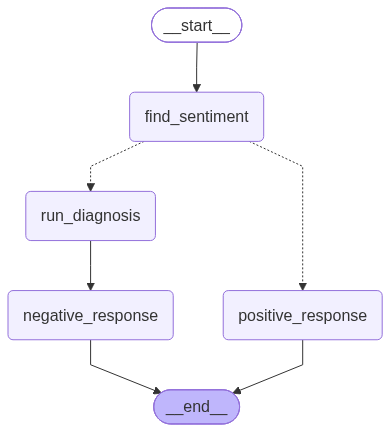

In [54]:
workflow

In [55]:
initial_state = {
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly"
}

result = workflow.invoke(initial_state)

In [56]:
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly',
 'sentiment': 'positive',
 'response': 'Hi [User’s Name],\n\nThank you so much for taking the time to share your thoughts! We’re thrilled to hear that you find the software’s clean interface and smooth performance helpful—and that it’s making a real difference in your workflow. Your kind words truly motivate our team to keep improving and delivering the best experience possible.\n\nIf you have a moment, we’d love for you to share your feedback on our website as well. Your insights help other users discover the benefits of the tool and guide us in shaping future updates.\n\nThanks again for your support!\n\nWarm regards,  \nThe [Your Company] Team'}

In [57]:
initial_state = {
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times."
}

result = workflow.invoke(initial_state)

In [58]:
result

{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'disappointed',
  'urgency': 'medium'},
 'response': 'Hi there,\n\nI’m really sorry to hear that you’re experiencing performance problems – I completely understand how frustrating that can be, especially when you’re counting on the service to work smoothly. Let’s see if we can get things back on track for you.\n\n### Quick‑Start Checklist\n1. **Refresh & Re‑login**  \n   - Log out of your account, clear your browser cache (or app data if you’re on mobile), and then log back in. This often resolves temporary hiccups.\n\n2. **Check Your Connection**  \n   - Ensure you have a stable internet connection (Wi‑Fi or cellular). If possible, try a different network or run a quick speed test (aim for\u202f>\u202f5\u202fMbps download).\n\n3. **Update the App/Browser**  \n   - Make sure you’re runn